In [1]:
# Mount drive

from google.colab import drive

drive.mount('/content/drive')

!pip -q install ultralytics

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.2 MB/s eta 0:00:00


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/VEDAI_slike/vedai.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, 

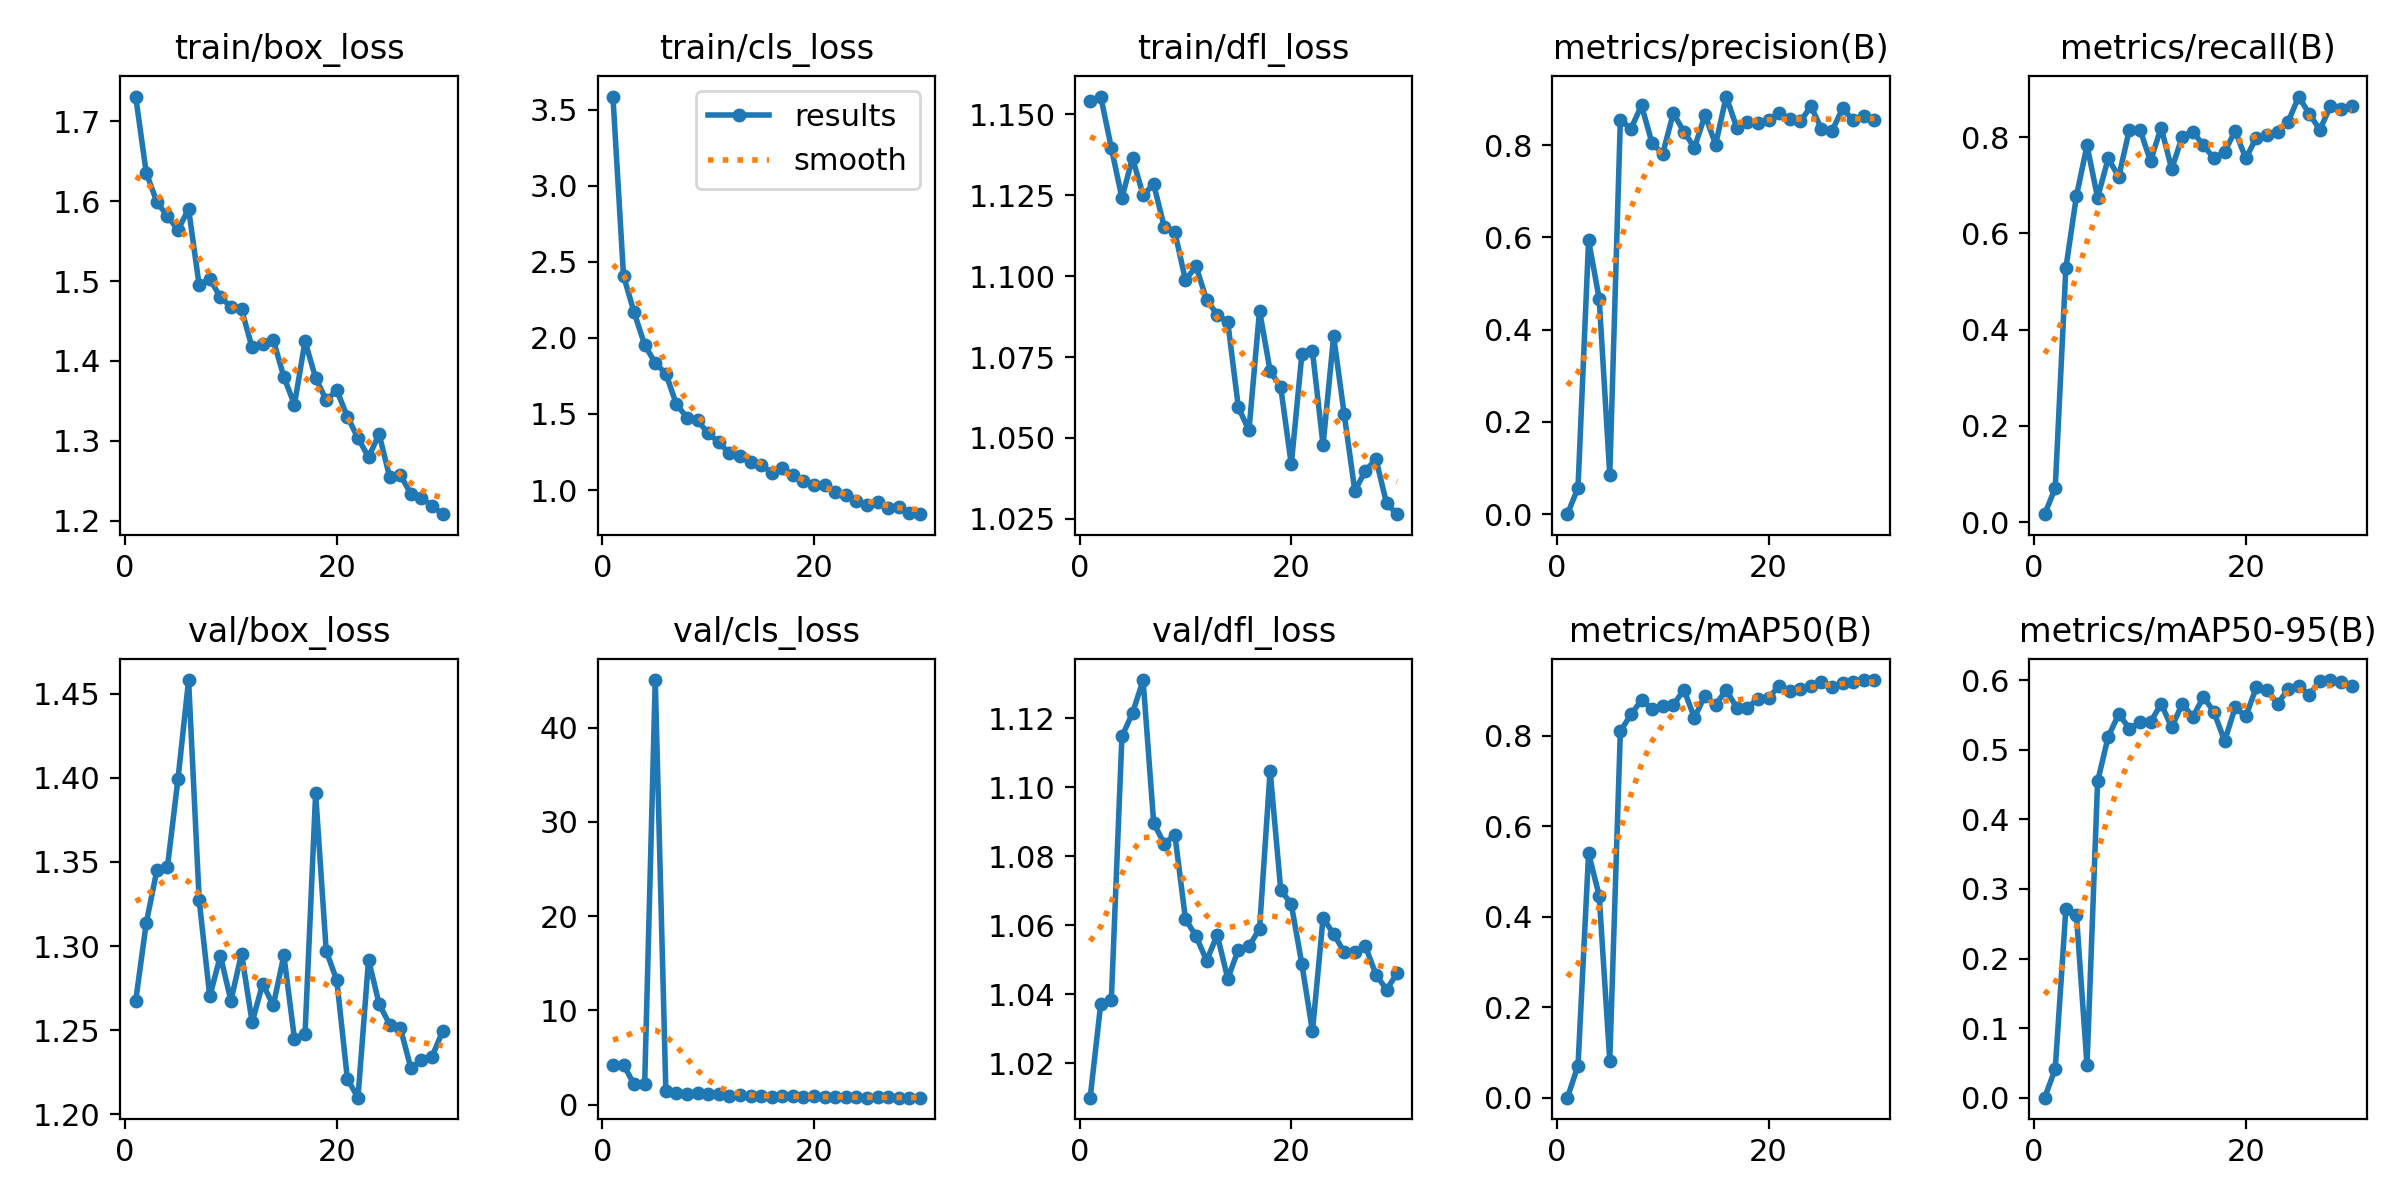

'/content/drive/MyDrive/VEDAI_slike/Rezultati/Yolo/metrics/loss.png'

In [2]:
# Import i treniranje YOLO modela

from ultralytics import YOLO
import os
import pandas as pd
import shutil
from IPython.display import display, Image

model = YOLO('yolov8n.pt')

results = model.train(
    data='/content/drive/MyDrive/VEDAI_slike/vedai.yaml',
    epochs=30,
    imgsz=1024,
    batch=8,
    device=0
)

pred_folder = "/content/drive/MyDrive/VEDAI_slike/Rezultati/Yolo/predictions"
metrics_folder = "/content/drive/MyDrive/VEDAI_slike/Rezultati/Yolo/metrics"

# Ispis i spremanje grafa treniranja
train_dir = model.trainer.save_dir

results_csv = os.path.join(train_dir, "results.csv")
df = pd.read_csv(results_csv)

for i, (train_loss, val_loss) in enumerate(zip(df['train/box_loss'], df['val/box_loss']), start=1):
    print(f"Epoch [{i}/{len(df)}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

results_path = os.path.join(train_dir, "results.png")
display(Image(filename=results_path))

metrics_path = os.path.join(metrics_folder, "loss.png")
shutil.copy(results_path, metrics_path)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 1.6±2.2 ms, read: 3.2±0.3 MB/s, size: 1688.4 KB)
val: Scanning /content/drive/MyDrive/VEDAI_slike/testiranje/labels.cache... 75 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 75/75 13.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 5.3s/it 26.5s
                   all         75        255      0.819      0.804       0.77      0.488
Speed: 2.6ms preprocess, 12.7ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val
Precision: 0.8190
Recall: 0.8039
F1 score: 0.8114
mAP50: 0.7702


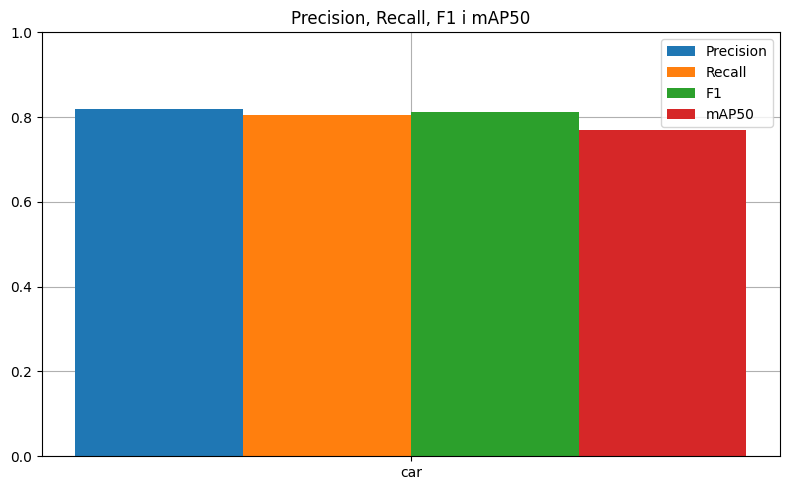

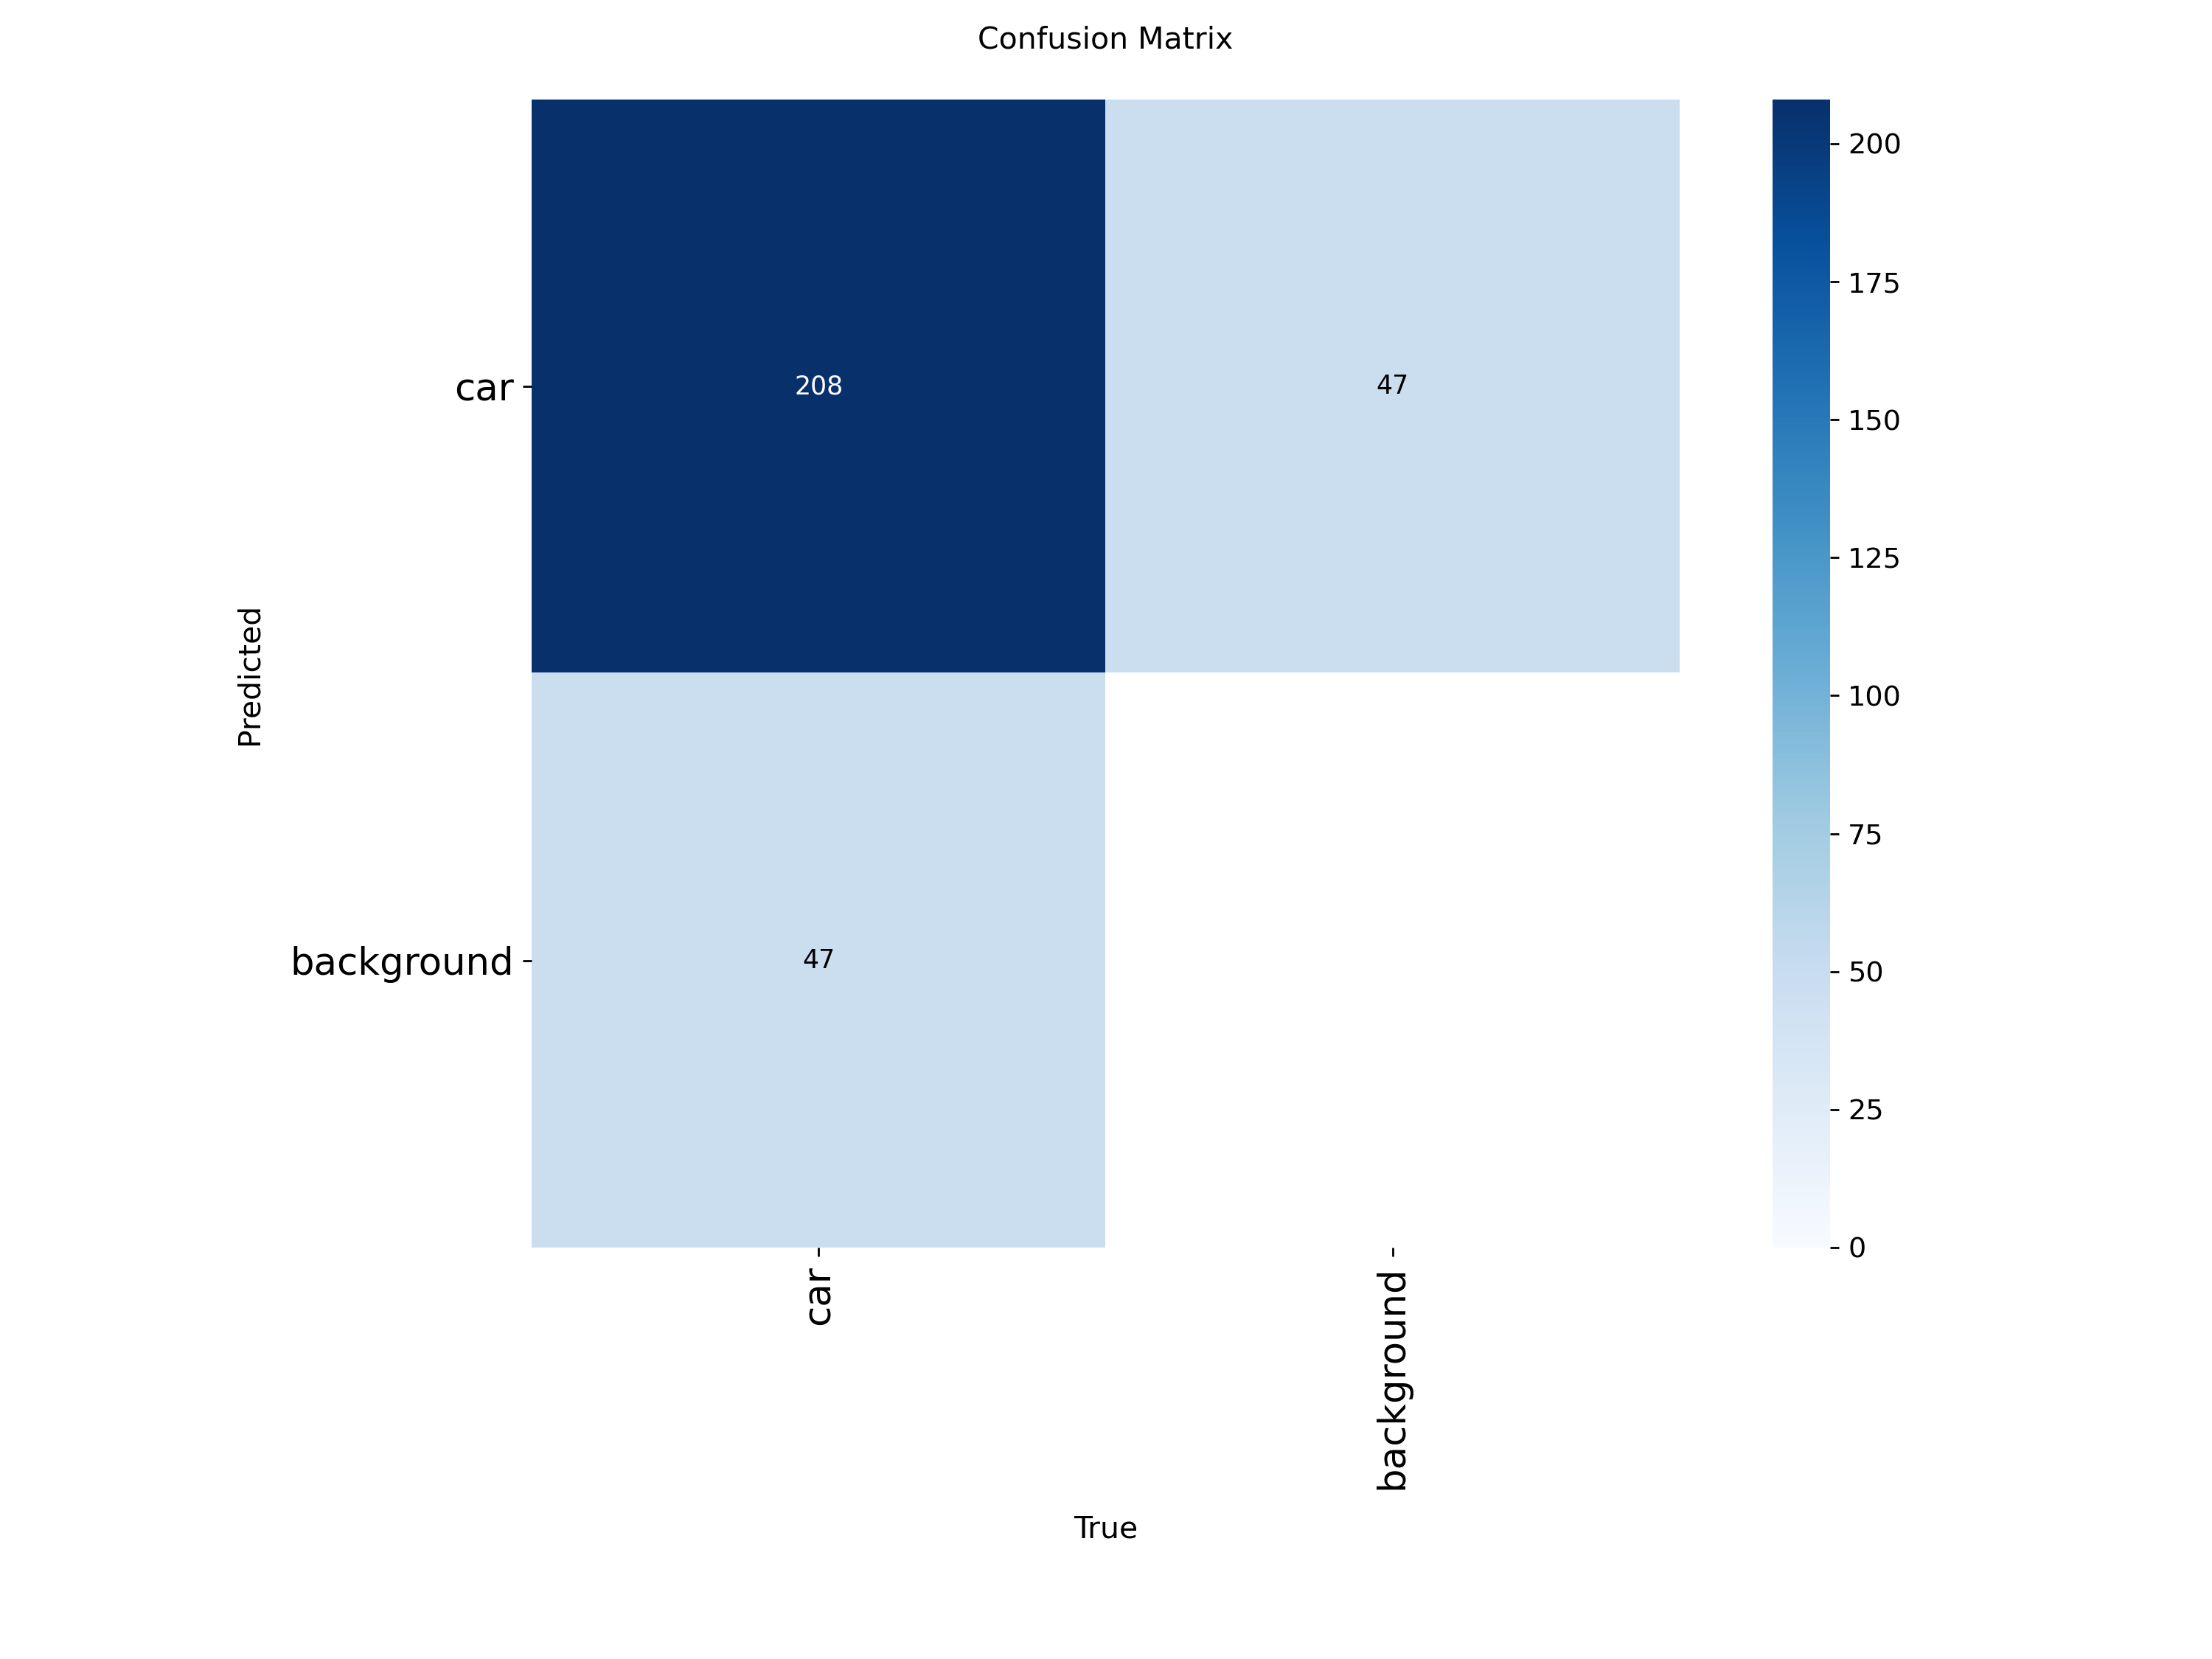

'/content/drive/MyDrive/VEDAI_slike/Rezultati/Yolo/metrics/confusion_matrix.png'

In [3]:
# Testiranje i ispis grafa metrika

import matplotlib.pyplot as plt
import numpy as np

bestmodel = YOLO("runs/detect/train/weights/best.pt")

valmetrics = bestmodel.val(
    data='/content/drive/MyDrive/VEDAI_slike/vedai.yaml',
    split='test',
    conf=0.25,
    iou=0.3
)

precision = valmetrics.box.p[0]
recall = valmetrics.box.r[0]
f1 = valmetrics.box.f1[0]
mAP50 = valmetrics.box.map50

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 score: {f1:.4f}")
print(f"mAP50: {mAP50:.4f}")

# Ispis grafa metrika
klase = ['car']

plt.figure(figsize=(8,5))
bar_width = 0.2
x = np.arange(len(klase))
plt.bar(x - bar_width*1.5, [precision], width=bar_width, label="Precision")
plt.bar(x - bar_width/2, [recall], width=bar_width, label="Recall")
plt.bar(x + bar_width/2, [f1], width=bar_width, label="F1")
plt.bar(x + bar_width*1.5, [mAP50], width=bar_width, label="mAP50")
plt.xticks(x, klase)
plt.ylim(0, 1)
plt.title("Precision, Recall, F1 i mAP50")
plt.grid(True)
plt.gca().set_axisbelow(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(metrics_folder, "metrics.png"))
plt.show()
plt.close()

# Ispis konfuzijske matrice
YOLO_conf_matrix_path = os.path.join(valmetrics.save_dir, "confusion_matrix.png")
print("\n\n")
display(Image(filename=YOLO_conf_matrix_path))

metrics_path = os.path.join(metrics_folder, "confusion_matrix.png")
shutil.copy(YOLO_conf_matrix_path, metrics_path)

In [4]:
# Ispis i spremanje predikcija na testnom skupu

import os
from glob import glob
import shutil
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
from ultralytics import YOLO

predict_results = bestmodel.predict(
    source="/content/drive/MyDrive/VEDAI_slike/testiranje/images",
    save=True,
    conf=0.25,
    iou=0.3,
    show_labels=False,
    show_conf=False
)

pred_dir = "/content/runs/detect/predict"
gt_folder = "/content/drive/MyDrive/VEDAI_slike/testiranje/labels"

slike = glob(os.path.join(pred_dir, "*.*"))
slike = [s for s in slike if s.endswith((".png", ".jpg", ".jpeg"))]

# Ispis i spremanje predikcija
for slika_path in slike:
    ime = os.path.basename(slika_path)
    dest_path = os.path.join(pred_folder, ime)

    shutil.copy(slika_path, dest_path)

    img = mpimg.imread(slika_path)
    h, w = img.shape[:2]

    fig, ax = plt.subplots(1, figsize=(8,8))
    ax.imshow(img)

    gt_path = os.path.join(gt_folder, os.path.splitext(ime)[0] + ".txt")

    if os.path.exists(gt_path):
        with open(gt_path, "r") as f:
            lines = f.readlines()
        for line in lines:
            cls, x_center, y_center, bw, bh = map(float, line.strip().split())

            x = (x_center - bw/2) * w
            y = (y_center - bh/2) * h
            bw_px = bw * w
            bh_px = bh * h

            # Crtanje GT
            rect = patches.Rectangle(
                (x, y),
                bw_px, bh_px,
                linewidth=1, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)

    ax.axis("off")
    ax.set_title(ime)
    fig.savefig(dest_path, bbox_inches='tight', pad_inches=0)
    plt.show()
    plt.close(fig)


Output hidden; open in https://colab.research.google.com to view.